# Digital Tribes: Analyzing Cross-Community Hostility on Reddit

**Team Notebook — Complete Analysis Walkthrough**

---

## What This Notebook Covers

This notebook walks through my complete analysis of Reddit cross-community interactions, comparing **political** and **sports** communities. The phases:

1. **Phase 1:** Load and prepare the data (camp definitions, event anchors)
2. **Phase 2:** Analyze baseline interaction patterns (heatmaps, LIWC signatures, reciprocity)
3. **Phase 3:** Examine how major events affect hostility (the "stress test")
4. **Phase 4:** Synthesize findings and draw conclusions

**Core Finding Preview:** The linguistic signature of hostility correlates at **r = 0.937** across politics and sports — anger sounds the same everywhere.

---

## 📦 Setup: Imports and Configuration

In [2]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Custom modules (built during analysis phases)
from data_prep import (
    load_prepared_data,
    POLITICS_CAMPS,
    SPORTS_CAMPS,
    EVENTS,
    TEXT_STRUCTURE_COLS,
    VADER_COLS,
    LIWC_COLS,
    get_camp_interactions,
    filter_around_event
)

from interaction_analysis import (
    build_interaction_matrix,
    get_camp_hostility_profile,
    analyze_reciprocity,
    get_liwc_by_sentiment,
    compare_liwc_signatures
)

from event_analysis import (
    analyze_all_events,
    compare_event_effects,
    get_weekly_trends
)

# Plotting configuration
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)

print("✓ All imports successful!")

✓ All imports successful!


---

# Phase 1: Data Preparation

In this phase, we load our datasets and explore the basic structure. The data consists of **cross-community posts** — instances where a post in one subreddit links to another subreddit.

**Key datasets:**
- `politics_body.csv` / `politics_title.csv` — Political subreddit interactions
- `sports_body.csv` / `sports_title.csv` — Sports subreddit interactions

## 1.1 Loading the Data

The `load_prepared_data()` function loads both domains, combines title and body data and adds camp labels based on our definitions.

Example: r/the_donald -> trump_conservative

In [3]:
# Load prepared data with camp labels
politics, sports = load_prepared_data()

print(f"Politics posts: {len(politics):,}")
print(f"Sports posts:   {len(sports):,}")
print(f"Total:          {len(politics) + len(sports):,}")
print(f"\nDate range: {politics['TIMESTAMP'].min().strftime('%Y-%m-%d')} to {politics['TIMESTAMP'].max().strftime('%Y-%m-%d')}")

Politics posts: 40,015
Sports posts:   27,727
Total:          67,742

Date range: 2014-01-01 to 2017-04-30


## 1.2 Data Structure

Each post has 86 features: metadata, text structure metrics, VADER sentiment, and 65 LIWC linguistic features.

In [4]:
# Preview the data structure
print("Sample columns:")
print(politics[['SOURCE_SUBREDDIT', 'TARGET_SUBREDDIT', 'LINK_SENTIMENT', 
                'source_camp', 'target_camp', 'VADER_NEG', 'LIWC_ANGER']].head())

Sample columns:
      SOURCE_SUBREDDIT TARGET_SUBREDDIT  LINK_SENTIMENT source_camp      target_camp  VADER_NEG  LIWC_ANGER
0           badhistory    worldpolitics               1       other  news_mainstream      0.189    0.016092
1  circlejerkcopypasta       mensrights              -1       other  gender_politics      0.240    0.017699
2           conspiracy  conspiratocracy               1  conspiracy            other      0.000    0.000000
3         stalkerwatch       conspiracy               1       other       conspiracy      0.096    0.009019
4           conspiracy             news               1  conspiracy  news_mainstream      0.000    0.000000


In [5]:
# Feature groups we have available
print(f"Text structure features: {len(TEXT_STRUCTURE_COLS)}")
print(f"VADER sentiment features: {len(VADER_COLS)}")
print(f"LIWC linguistic features: {len(LIWC_COLS)}")
print(f"\nTotal features per post: {len(TEXT_STRUCTURE_COLS) + len(VADER_COLS) + len(LIWC_COLS)}")

Text structure features: 18
VADER sentiment features: 3
LIWC linguistic features: 65

Total features per post: 86


## 1.3 Camp Definitions

Subreddits into "camps" — clusters of related communities. This allows us to analyze group-level behavior rather than individual subreddits.

In [6]:
# Political camps
print("POLITICAL CAMPS:")
print("=" * 50)
for camp, subreddits in POLITICS_CAMPS.items():
    print(f"\n{camp}:")
    print(f"  {', '.join(subreddits[:5])}{'...' if len(subreddits) > 5 else ''}")

POLITICAL CAMPS:

trump_conservative:
  the_donald, conservative, republican, hillaryforprison, asktrumpsupporters...

libertarian:
  anarcho_capitalism, libertarian, goldandblack, shitstatistssay, garyjohnson...

progressive:
  sandersforpresident, wayofthebern, kossacks_for_sanders, stillsandersforpres, socialism...

anti_trump:
  enoughtrumpspam, enough_sanders_spam, shitrconservativesays, circlebroke2, againsthatesubreddits...

alt_right:
  european, whiterights, uncensorednews, postnationalist, metacanada

conspiracy:
  conspiracy, conspiratard, undelete

news_mainstream:
  politics, worldpolitics, worldnews, news, politic...

gender_politics:
  mensrights, theredpill, againstmensrights

meta_drama:
  subredditdrama, drama, bestof, shitliberalssay, bestofoutrageculture...


In [7]:
# Sports camps (summarized)
print("SPORTS CAMPS:")
print("=" * 50)
for camp, subreddits in list(SPORTS_CAMPS.items())[:8]:  # Show first 8
    print(f"\n{camp}:")
    print(f"  {', '.join(subreddits[:4])}{'...' if len(subreddits) > 4 else ''}")
print("\n... and 6 more camps (NFL divisions, etc.)")

SPORTS CAMPS:

nfl_general:
  nfl, nfl_draft, fantasyfootball

afc_east:
  patriots, buffalobills, miamidolphins, nyjets

afc_north:
  browns, bengals, ravens, steelers

afc_south:
  texans, tennesseetitans, colts, jaguars

afc_west:
  oaklandraiders, denverbroncos, chargers, kansascitychiefs

nfc_east:
  eagles, cowboys, redskins, nygiants

nfc_north:
  greenbaypackers, chibears, minnesotavikings, detroitlions

nfc_south:
  panthers, falcons, saints, buccaneers

... and 6 more camps (NFL divisions, etc.)


## 1.4 Camp Coverage Statistics

How much of our data we cover using these camps vs. "other"?

In [8]:
# Calculate camp coverage
pol_source_coverage = (politics['source_camp'] != 'other').mean() * 100
pol_target_coverage = (politics['target_camp'] != 'other').mean() * 100
sport_source_coverage = (sports['source_camp'] != 'other').mean() * 100
sport_target_coverage = (sports['target_camp'] != 'other').mean() * 100

print("Camp Coverage:")
print(f"  Politics - Source: {pol_source_coverage:.1f}%, Target: {pol_target_coverage:.1f}%")
print(f"  Sports   - Source: {sport_source_coverage:.1f}%, Target: {sport_target_coverage:.1f}%")

Camp Coverage:
  Politics - Source: 66.5%, Target: 61.3%
  Sports   - Source: 57.8%, Target: 79.9%


## 1.5 Baseline Hostility Rates

Our first key finding: **Politics is significantly more hostile than sports.**

In [9]:
# Calculate baseline hostility
pol_neg_rate = (politics['LINK_SENTIMENT'] == -1).mean()
sport_neg_rate = (sports['LINK_SENTIMENT'] == -1).mean()

print(f"Baseline Hostility Rates:")
print(f"  Politics: {pol_neg_rate*100:.1f}% negative")
print(f"  Sports:   {sport_neg_rate*100:.1f}% negative")
print(f"\n  → Politics is {pol_neg_rate/sport_neg_rate:.1f}x more hostile")

Baseline Hostility Rates:
  Politics: 17.3% negative
  Sports:   5.2% negative

  → Politics is 3.3x more hostile


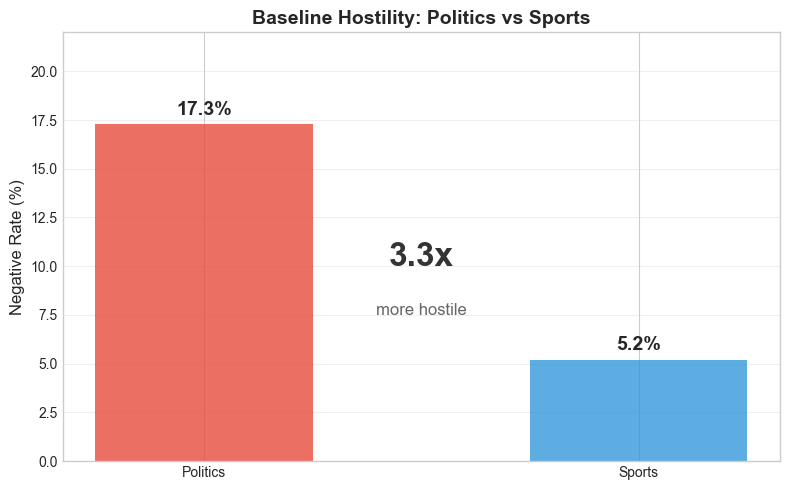

In [13]:
# Visualize the difference
fig, ax = plt.subplots(figsize=(8, 5))

domains = ['Politics', 'Sports']
rates = [pol_neg_rate * 100, sport_neg_rate * 100]
colors = ['#e74c3c', '#3498db']

bars = ax.bar(domains, rates, color=colors, alpha=0.8, width=0.5)

# Add value labels
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{rate:.1f}%', ha='center', fontsize=14, fontweight='bold')

# Add ratio annotation
ax.annotate('3.3x', xy=(0.5, 10), fontsize=24, fontweight='bold', 
            ha='center', color='#333')
ax.annotate('more hostile', xy=(0.5, 7.5), fontsize=12, ha='center', color='#666')

ax.set_ylabel('Negative Rate (%)', fontsize=12)
ax.set_title('Baseline Hostility: Politics vs Sports', fontsize=14, fontweight='bold')
ax.set_ylim(0, 22)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 1.6 Events We'll Analyze

The events defined in both domains to test how they affect hostility patterns.

In [14]:
# Show defined events
print("EVENTS FOR ANALYSIS:")
print("=" * 60)
for domain in ['politics', 'sports']:
    print(f"\n{domain.upper()}:")
    domain_events = EVENTS[EVENTS['domain'] == domain]
    for _, event in domain_events.iterrows():
        print(f"  • {event['name']} ({event['date'].strftime('%Y-%m-%d')})")

EVENTS FOR ANALYSIS:

POLITICS:
  • 2016 US Election (2016-11-08)
  • Brexit Referendum (2016-06-23)
  • Super Tuesday 2016 (2016-03-01)
  • RNC Convention Start (2016-07-18)
  • DNC Convention Start (2016-07-25)
  • First Presidential Debate (2016-09-26)
  • Second Presidential Debate (2016-10-09)
  • Trump Inauguration (2017-01-20)

SPORTS:
  • Super Bowl LI (Patriots vs Falcons) (2017-02-05)
  • Super Bowl 50 (Broncos vs Panthers) (2016-02-07)
  • Super Bowl XLIX (Patriots vs Seahawks) (2015-02-01)
  • Super Bowl XLVIII (Seahawks vs Broncos) (2014-02-02)
  • NBA Finals 2016 Game 7 (Cavs vs Warriors) (2016-06-19)
  • NBA Finals 2015 Game 6 (Warriors win) (2015-06-16)


---

# Phase 2: Interaction Analysis

Now we dig into **who interacts with whom** and **how hostile those interactions are**. This phase reveals the structure of tribal conflict.

## 2.1 Camp-to-Camp Interaction Matrices

The `build_interaction_matrix()` function creates a heatmap showing hostility between camps.

In [30]:
# Build interaction matrices
# min_count=50 ensures we only show pairs with enough data
pol_matrix = build_interaction_matrix(politics, metric='negative_rate', min_count=10)
sport_matrix = build_interaction_matrix(sports, metric='negative_rate', min_count=10)

print(f"Politics matrix: {pol_matrix.shape[0]} camps × {pol_matrix.shape[1]} camps")
print(f"Sports matrix: {sport_matrix.shape[0]} camps × {sport_matrix.shape[1]} camps")

Politics matrix: 9 camps × 9 camps
Sports matrix: 14 camps × 13 camps


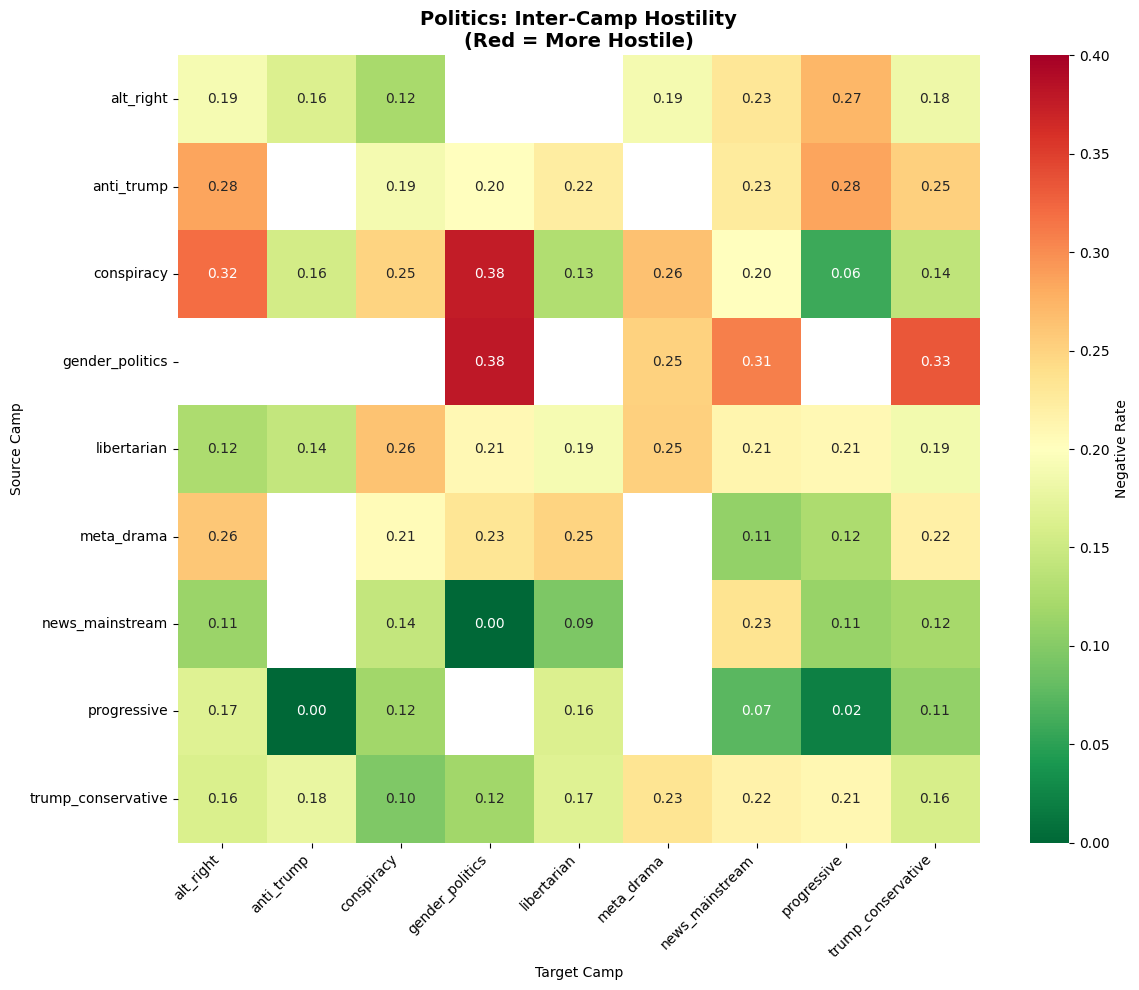

In [31]:
# Visualize politics heatmap
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(pol_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r',
            vmin=0, vmax=0.4, ax=ax, cbar_kws={'label': 'Negative Rate'})

ax.set_title('Politics: Inter-Camp Hostility\n(Red = More Hostile)', fontsize=14, fontweight='bold')
ax.set_xlabel('Target Camp')
ax.set_ylabel('Source Camp')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

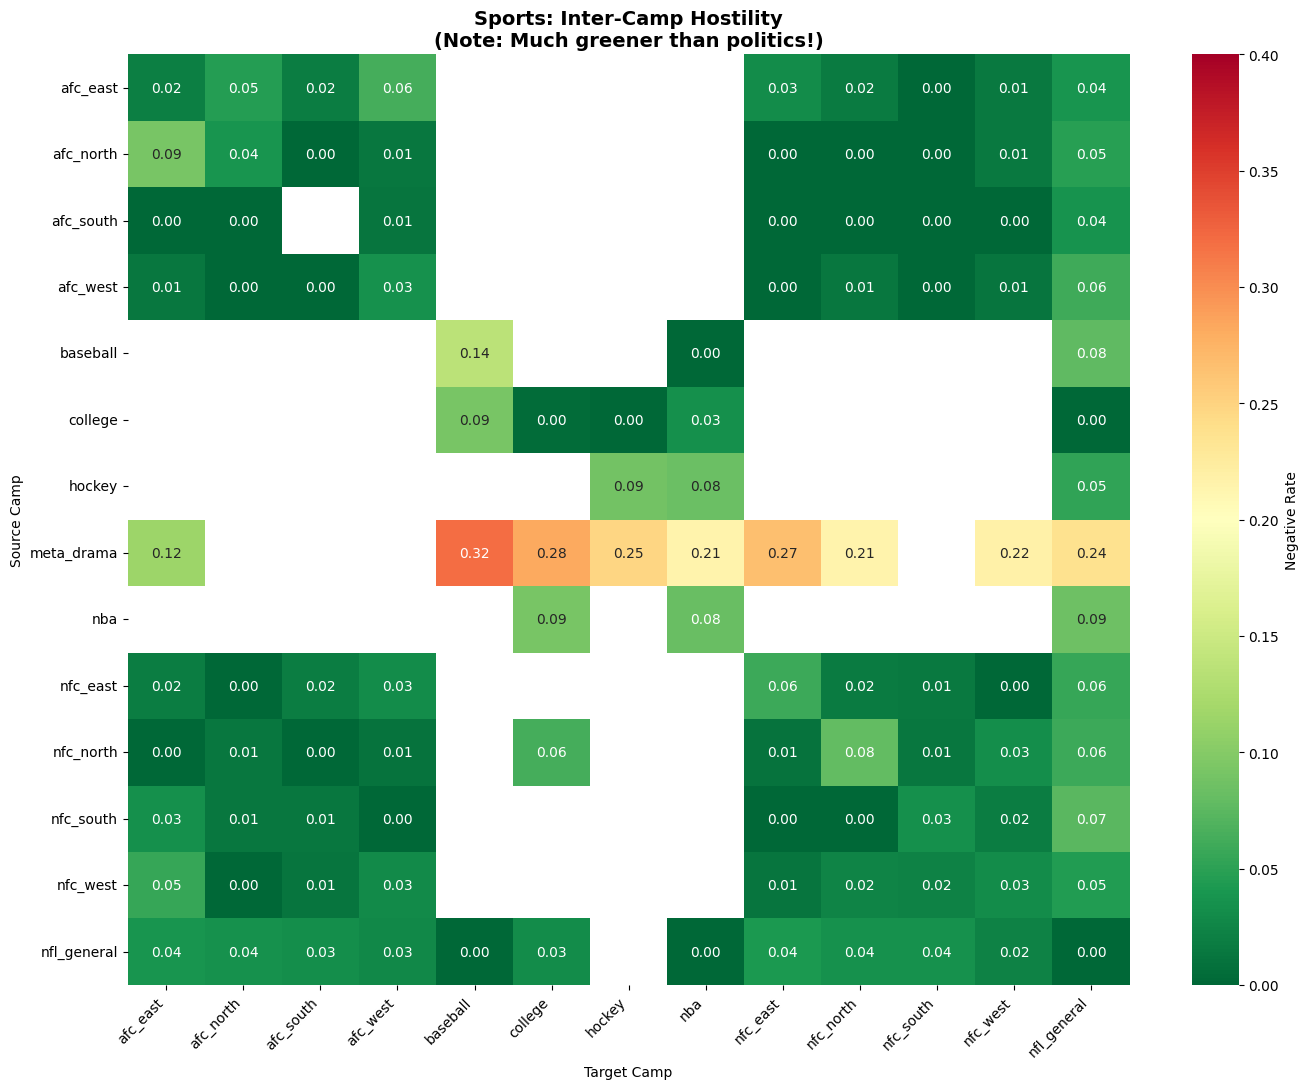

In [32]:
# Visualize sports heatmap
fig, ax = plt.subplots(figsize=(14, 11))

sns.heatmap(sport_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r',
            vmin=0, vmax=0.4, ax=ax, cbar_kws={'label': 'Negative Rate'})

ax.set_title('Sports: Inter-Camp Hostility\n(Note: Much greener than politics!)', fontsize=14, fontweight='bold')
ax.set_xlabel('Target Camp')
ax.set_ylabel('Source Camp')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 📌 Observation

Notice how the politics heatmap is dominated by oranges and reds (high hostility), while sports is mostly green (low hostility).

The exception? **meta_drama**, which is hostile in both domains!

## 2.2 Most Hostile Camps

Which camps are the most aggressive when posting about others?

In [33]:
# Get hostility profiles,
# this function also returns incoming hostility and if they're an agressor or not
pol_profile = get_camp_hostility_profile(politics)
sport_profile = get_camp_hostility_profile(sports)

print("MOST HOSTILE CAMPS (Outgoing):")
print("\nPolitics:")
print(pol_profile[['camp', 'outgoing_neg_rate']].head(5).to_string(index=False))

print("\nSports:")
print(sport_profile[['camp', 'outgoing_neg_rate']].head(5).to_string(index=False))

MOST HOSTILE CAMPS (Outgoing):

Politics:
           camp  outgoing_neg_rate
gender_politics           0.343164
     anti_trump           0.245663
     meta_drama           0.224109
      alt_right           0.212792
    libertarian           0.204428

Sports:
      camp  outgoing_neg_rate
meta_drama           0.249084
  baseball           0.118143
    hockey           0.084980
       nba           0.082667
 nfc_north           0.038118


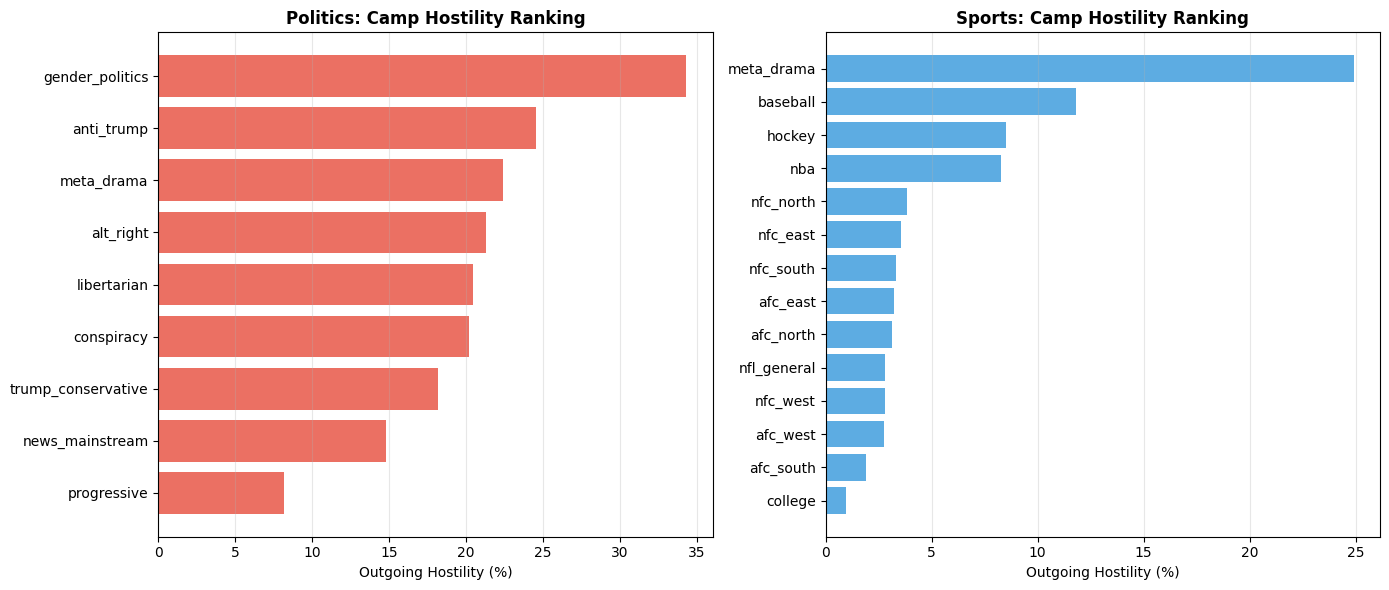

In [34]:
# Visualize camp profiles
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Politics
pol_sorted = pol_profile.sort_values('outgoing_neg_rate', ascending=True)
axes[0].barh(pol_sorted['camp'], pol_sorted['outgoing_neg_rate'] * 100, color='#e74c3c', alpha=0.8)
axes[0].set_xlabel('Outgoing Hostility (%)')
axes[0].set_title('Politics: Camp Hostility Ranking', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Sports
sport_sorted = sport_profile.sort_values('outgoing_neg_rate', ascending=True)
axes[1].barh(sport_sorted['camp'], sport_sorted['outgoing_neg_rate'] * 100, color='#3498db', alpha=0.8)
axes[1].set_xlabel('Outgoing Hostility (%)')
axes[1].set_title('Sports: Camp Hostility Ranking', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 2.3 Reciprocity Analysis: Who Attacks Whom?

Are rivalries symmetric (mutual hostility) or asymmetric (one-sided attacks)?

In [35]:
# Analyze reciprocity,
# Function also returns the type of relationship and very useful information to compare 2 camps!
pol_recip = analyze_reciprocity(politics, min_count=50)

print("MOST ASYMMETRIC RIVALRIES (Politics):")
print("(Positive asymmetry = camp_a more hostile toward camp_b)\n")

asymmetric = pol_recip.sort_values('asymmetry', key=abs, ascending=False).head(6)
print(asymmetric[['camp_a', 'camp_b', 'a_to_b_neg_rate', 'b_to_a_neg_rate', 'asymmetry']].to_string(index=False))

MOST ASYMMETRIC RIVALRIES (Politics):
(Positive asymmetry = camp_a more hostile toward camp_b)

            camp_a             camp_b  a_to_b_neg_rate  b_to_a_neg_rate  asymmetry
         alt_right    news_mainstream         0.230903         0.112903   0.118000
       progressive trump_conservative         0.109091         0.210526  -0.101435
trump_conservative    news_mainstream         0.216749         0.121622   0.095127
        anti_trump trump_conservative         0.252366         0.177215   0.075151
        conspiracy        progressive         0.057971         0.117647  -0.059676
        meta_drama         conspiracy         0.205184         0.264151  -0.058967


### 📌 Key Finding: Asymmetric Hostility

**alt_right → news_mainstream** shows 2x asymmetry: alt_right attacks mainstream news (23%) much more than the reverse (11%). This suggests directional conflict patterns.

## 2.4 The Universal Hostility Signature (LIWC Analysis)

This is the **core finding**. We compare how LIWC features change in hostile vs. friendly posts across both sports and politics.

In [36]:
# Get LIWC signatures for each domain
# 'difference' = mean(negative posts) - mean(positive posts)
pol_liwc = get_liwc_by_sentiment(politics)
sport_liwc = get_liwc_by_sentiment(sports)

pol_sig = pol_liwc['difference']  # The "hostility signature"
sport_sig = sport_liwc['difference']

print("Top LIWC features elevated in hostile posts:")
print("\nPolitics:")
print(pol_sig.sort_values(ascending=False).head(8).to_string())
print("\nSports:")
print(sport_sig.sort_values(ascending=False).head(8).to_string())

Top LIWC features elevated in hostile posts:

Politics:
LIWC_NEGEMO    0.042486
LIWC_AFFECT    0.038533
LIWC_FUNCT     0.035132
LIWC_ANGER     0.031027
LIWC_SOC       0.015676
LIWC_PRON      0.011587
LIWC_BIO       0.011502
LIWC_COG       0.010602

Sports:
LIWC_FUNCT     0.082340
LIWC_AFFECT    0.057761
LIWC_NEGEMO    0.057231
LIWC_ANGER     0.044458
LIWC_VERB      0.031603
LIWC_PRES      0.028985
LIWC_PRON      0.022844
LIWC_SWEAR     0.021604


In [37]:
# THE KEY CALCULATION: Cross-domain correlation
correlation = pol_sig.corr(sport_sig)
spearman = stats.spearmanr(pol_sig, sport_sig)[0]

print("=" * 50)
print("CROSS-DOMAIN LIWC CORRELATION")
print("=" * 50)
print(f"\n  Pearson r:  {correlation:.3f}")
print(f"  Spearman ρ: {spearman:.3f}")
print("\n  → Hostility uses nearly IDENTICAL vocabulary")
print("    across politics and sports!")
print("=" * 50)

CROSS-DOMAIN LIWC CORRELATION

  Pearson r:  0.937
  Spearman ρ: 0.860

  → Hostility uses nearly IDENTICAL vocabulary
    across politics and sports!


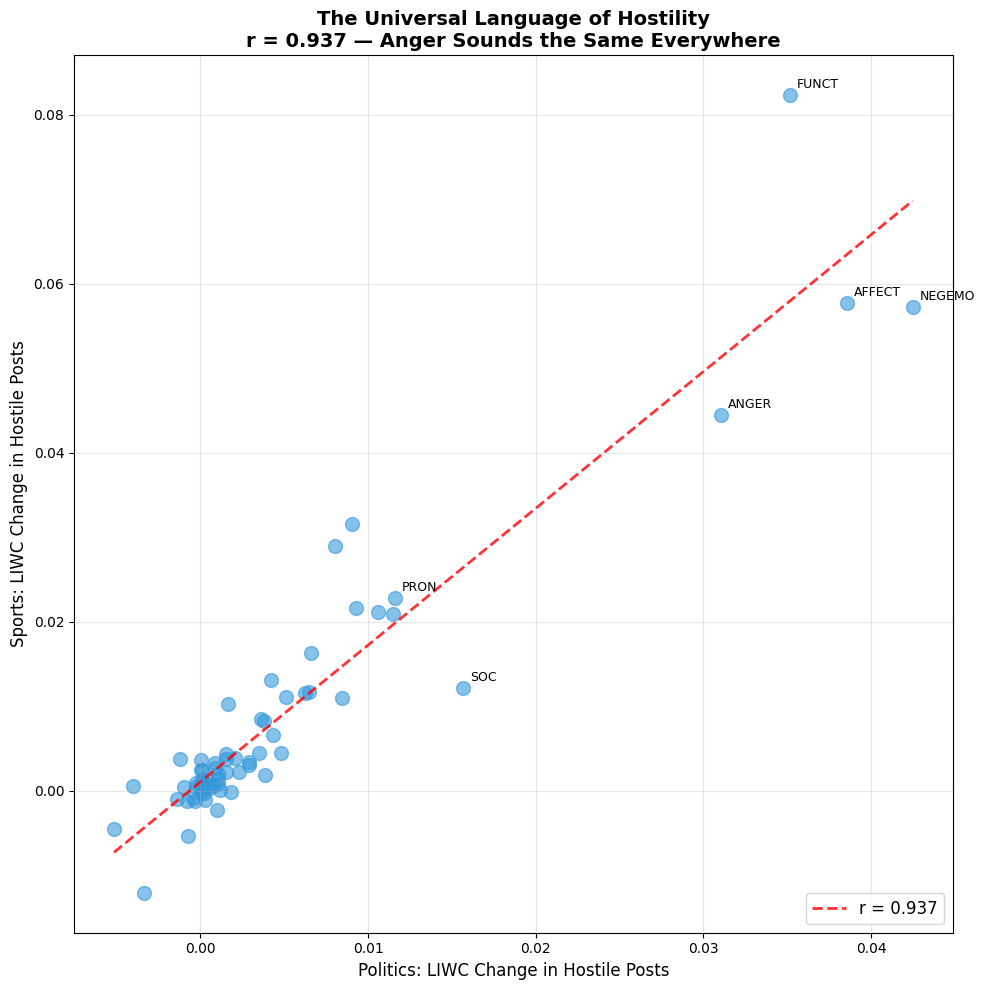

In [38]:
# Visualize the correlation (THE MONEY SHOT)
fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(pol_sig, sport_sig, alpha=0.6, s=100, c='#3498db')

# Label top features
for feat in pol_sig.sort_values(ascending=False).head(6).index:
    ax.annotate(feat.replace('LIWC_', ''), 
                (pol_sig[feat], sport_sig[feat]),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

# Add regression line
z = np.polyfit(pol_sig, sport_sig, 1)
p = np.poly1d(z)
x_line = np.linspace(pol_sig.min(), pol_sig.max(), 100)
ax.plot(x_line, p(x_line), 'r--', alpha=0.8, linewidth=2, label=f'r = {correlation:.3f}')

ax.set_xlabel('Politics: LIWC Change in Hostile Posts', fontsize=12)
ax.set_ylabel('Sports: LIWC Change in Hostile Posts', fontsize=12)
ax.set_title('The Universal Language of Hostility\nr = 0.937 — Anger Sounds the Same Everywhere', 
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

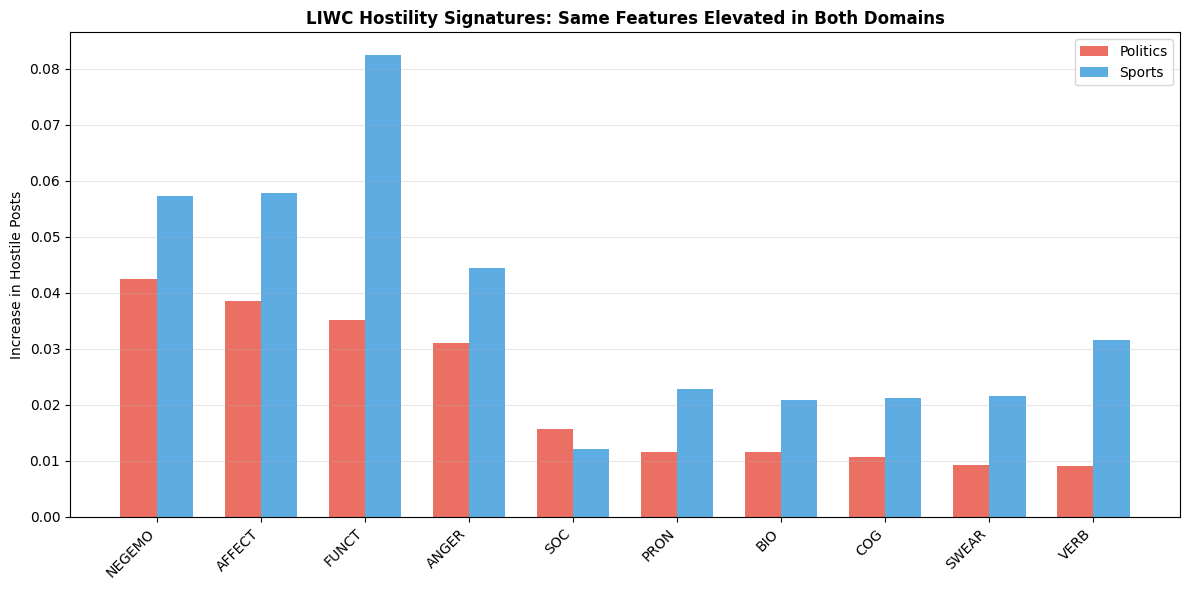

In [39]:
# Side-by-side comparison of top features
top_features = pol_sig.sort_values(ascending=False).head(10).index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(top_features))
width = 0.35

bars1 = ax.bar(x - width/2, [pol_sig[f] for f in top_features], width, 
               label='Politics', color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x + width/2, [sport_sig[f] for f in top_features], width,
               label='Sports', color='#3498db', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([f.replace('LIWC_', '') for f in top_features], rotation=45, ha='right')
ax.set_ylabel('Increase in Hostile Posts')
ax.set_title('LIWC Hostility Signatures: Same Features Elevated in Both Domains', 
             fontsize=12, fontweight='bold')
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 📌 Core Finding: r = 0.937

This is the central insight of our analysis:

- **Politics is 3x more hostile** overall
- **But when hostility occurs**, it uses nearly identical language
- Same increase in: NEGEMO, ANGER, SWEAR, AFFECT, COG
- **"Whether you're fighting about Trump or Tom Brady, anger sounds the same"**

---

# Phase 3: Event Analysis (The Stress Test)

Here we test our findings and analyse them during big events: elections, Super Bowls, Brexit. Do patterns change ? Or do they just amplify existing behaviors?

## 3.1 Analyzing All Events

In [24]:
# Analyze all events
# We compare hostility 7 days before and 7 days after (which creates the baseline rate) vs during the day of the event.
all_analyses = analyze_all_events(politics, sports, EVENTS)
effects = compare_event_effects(all_analyses)

print("EVENT EFFECTS ON HOSTILITY:")
print("(absolute_effect = during_rate - baseline_rate)\n")
print(effects[['event_name', 'domain', 'baseline_neg_rate', 'during_neg_rate', 'absolute_effect']].to_string(index=False))

EVENT EFFECTS ON HOSTILITY:
(absolute_effect = during_rate - baseline_rate)

                               event_name   domain  baseline_neg_rate  during_neg_rate  absolute_effect
      Super Bowl LI (Patriots vs Falcons)   sports           0.021543         0.103448         0.081905
                        Brexit Referendum politics           0.142835         0.205128         0.062293
NBA Finals 2016 Game 7 (Cavs vs Warriors)   sports           0.049820         0.105263         0.055443
               Second Presidential Debate politics           0.176724         0.229167         0.052443
   Super Bowl XLIX (Patriots vs Seahawks)   sports           0.068462         0.111111         0.042649
                       Trump Inauguration politics           0.157727         0.193548         0.035822
                         2016 US Election politics           0.127187         0.151899         0.024712
      Super Bowl 50 (Broncos vs Panthers)   sports           0.024072         0.022727     

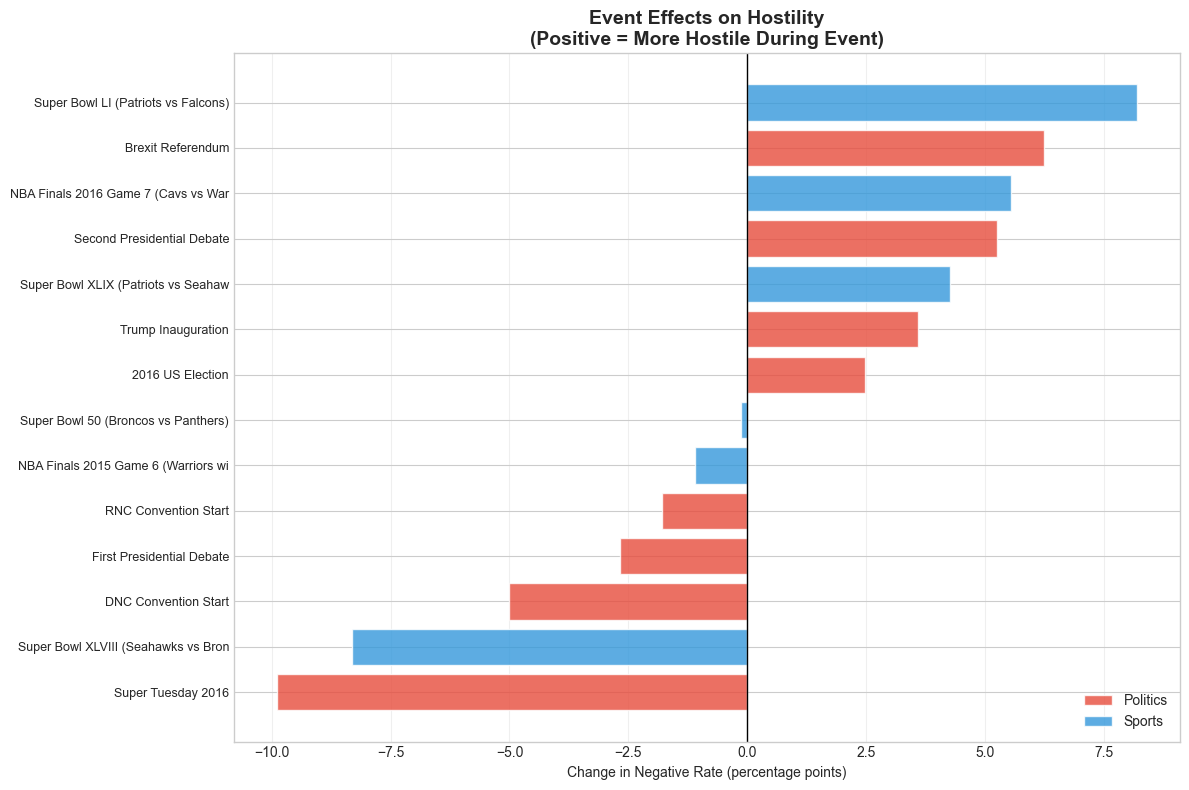

In [25]:
# Visualize event effects
fig, ax = plt.subplots(figsize=(12, 8))

effects_sorted = effects.sort_values('absolute_effect', ascending=True)
colors = ['#e74c3c' if d == 'politics' else '#3498db' for d in effects_sorted['domain']]

y = np.arange(len(effects_sorted))
ax.barh(y, effects_sorted['absolute_effect'] * 100, color=colors, alpha=0.8)

ax.set_yticks(y)
ax.set_yticklabels(effects_sorted['event_name'].str[:35], fontsize=9)
ax.set_xlabel('Change in Negative Rate (percentage points)')
ax.set_title('Event Effects on Hostility\n(Positive = More Hostile During Event)', 
             fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=1)
ax.grid(axis='x', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', alpha=0.8, label='Politics'),
                   Patch(facecolor='#3498db', alpha=0.8, label='Sports')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

You can see some events clearly create more anger like 'Super Bowl LI', but there's also some that do the opposite and unite people like 'Super Tuesday'!

## 3.2 Before / During / After Analysis

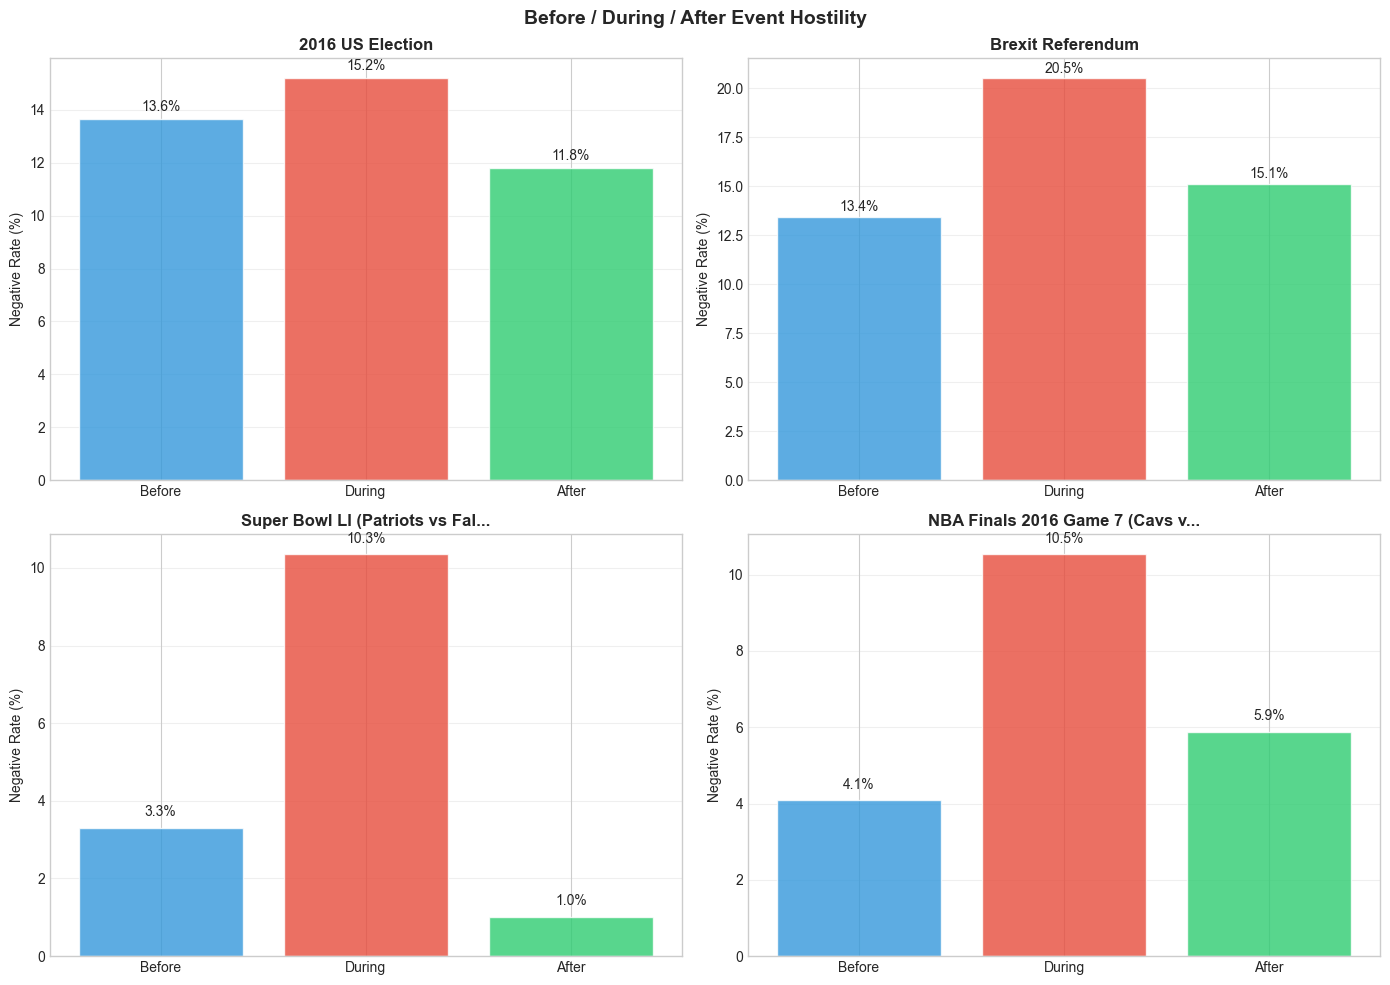

In [26]:
# Pick key events to analyze in detail
key_events = ['2016 US Election', 'Brexit Referendum', 
              'Super Bowl LI (Patriots vs Falcons)', 'NBA Finals 2016 Game 7 (Cavs vs Warriors)']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, event_name in zip(axes.flat, key_events):
    analysis = all_analyses[event_name]
    periods = analysis['period_stats']
    
    x = ['Before', 'During', 'After']
    y = [periods['before']['negative_rate'] * 100,
         periods['during']['negative_rate'] * 100,
         periods['after']['negative_rate'] * 100]
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    
    bars = ax.bar(x, y, color=colors, alpha=0.8)
    ax.set_ylabel('Negative Rate (%)')
    ax.set_title(event_name[:30] + ('...' if len(event_name) > 30 else ''), fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar, val in zip(bars, y):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
                f'{val:.1f}%', ha='center', fontsize=10)

plt.suptitle('Before / During / After Event Hostility', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.3 Timeline View

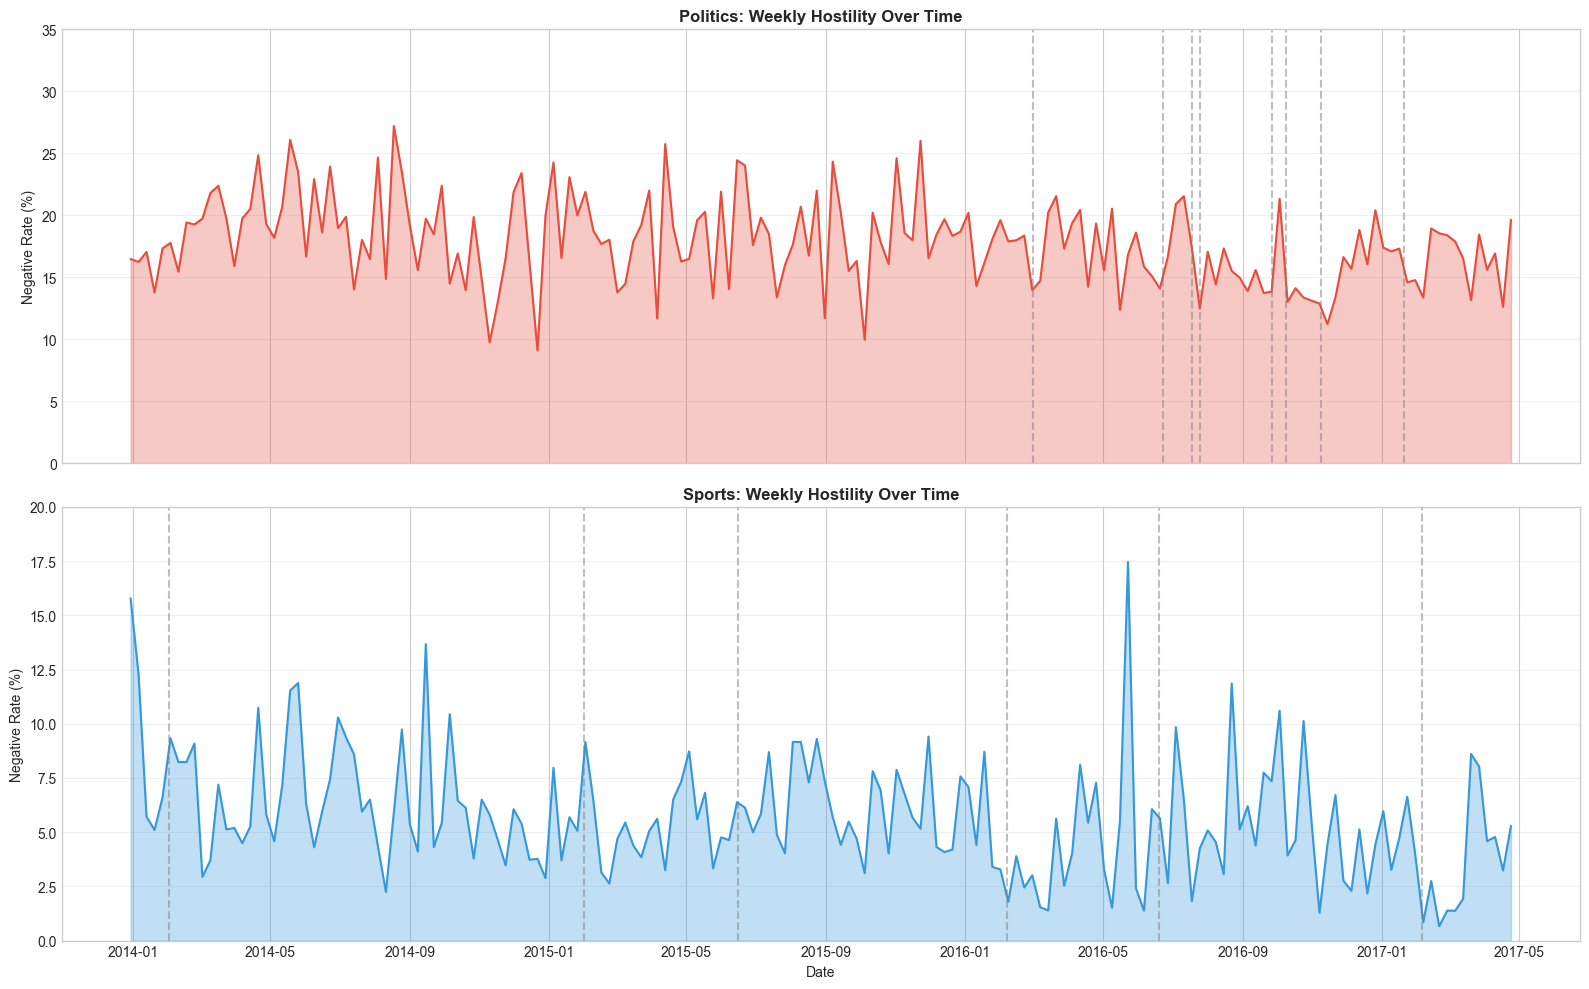

In [27]:
# Weekly trends with events marked
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Politics
pol_weekly = get_weekly_trends(politics)
axes[0].fill_between(pol_weekly['week'], pol_weekly['negative_rate'] * 100, alpha=0.3, color='#e74c3c')
axes[0].plot(pol_weekly['week'], pol_weekly['negative_rate'] * 100, color='#e74c3c', linewidth=1.5)

# Mark events
for _, event in EVENTS[EVENTS['domain'] == 'politics'].iterrows():
    axes[0].axvline(x=event['date'], color='gray', linestyle='--', alpha=0.5)

axes[0].set_ylabel('Negative Rate (%)')
axes[0].set_title('Politics: Weekly Hostility Over Time', fontweight='bold')
axes[0].set_ylim(0, 35)
axes[0].grid(axis='y', alpha=0.3)

# Sports
sport_weekly = get_weekly_trends(sports)
axes[1].fill_between(sport_weekly['week'], sport_weekly['negative_rate'] * 100, alpha=0.3, color='#3498db')
axes[1].plot(sport_weekly['week'], sport_weekly['negative_rate'] * 100, color='#3498db', linewidth=1.5)

# Mark events
for _, event in EVENTS[EVENTS['domain'] == 'sports'].iterrows():
    axes[1].axvline(x=event['date'], color='gray', linestyle='--', alpha=0.5)

axes[1].set_ylabel('Negative Rate (%)')
axes[1].set_xlabel('Date')
axes[1].set_title('Sports: Weekly Hostility Over Time', fontweight='bold')
axes[1].set_ylim(0, 20)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 📌 Event Analysis Findings

1. **Effects are unpredictable** — Some events increase hostility, others decrease it
2. **Largest spike: Super Bowl LI** (+8.2 pp) — sports can get heated!
3. **Effects are temporary** — Hostility returns to baseline after events
4. **No systematic pattern** — Events don't fundamentally change tribal behavior

---

# Phase 4: Synthesis

Putting all together!

## 4.1 The meta_drama Pattern

One camp appears in both domains with nearly identical behavior: **meta_drama** (subredditdrama, bestof). This camp normally has people that just "observe".

In [29]:
# Compare meta_drama across domains
pol_meta = pol_profile[pol_profile['camp'] == 'meta_drama']['outgoing_neg_rate'].values[0]
sport_meta = sport_profile[sport_profile['camp'] == 'meta_drama']['outgoing_neg_rate'].values[0]

print("meta_drama Hostility:")
print(f"  In Politics: {pol_meta*100:.1f}%")
print(f"  In Sports:   {sport_meta*100:.1f}%")
print(f"\n  → The 'observers' are equally hostile regardless of what they observe!")

meta_drama Hostility:
  In Politics: 22.4%
  In Sports:   24.9%

  → The 'observers' are equally hostile regardless of what they observe!


## 4.2 Summary Statistics

In [30]:
# Calculate key summary stats
top_pol_features = set(pol_sig.sort_values(ascending=False).head(10).index)
top_sport_features = set(sport_sig.sort_values(ascending=False).head(10).index)
shared_features = top_pol_features & top_sport_features

pol_events = effects[effects['domain'] == 'politics']
sport_events = effects[effects['domain'] == 'sports']

print("=" * 60)
print("KEY STATISTICS SUMMARY")
print("=" * 60)
print(f"""
DATASET:
  • Total posts analyzed: {len(politics) + len(sports):,}
  • Date range: Jan 2014 – Apr 2017
  • Political camps: {len(POLITICS_CAMPS)}
  • Sports camps: {len(SPORTS_CAMPS)}

BASELINE HOSTILITY:
  • Politics: {pol_neg_rate*100:.1f}% negative
  • Sports: {sport_neg_rate*100:.1f}% negative  
  • Ratio: {pol_neg_rate/sport_neg_rate:.1f}x more hostile in politics

THE UNIVERSAL SIGNATURE:
  • LIWC correlation: r = {correlation:.3f}
  • Shared top-10 features: {len(shared_features)}/10
  • Key features: NEGEMO, ANGER, SWEAR, AFFECT, COG

EVENT EFFECTS:
  • Politics avg effect: {pol_events['absolute_effect'].mean()*100:+.1f} pp
  • Sports avg effect: {sport_events['absolute_effect'].mean()*100:+.1f} pp
  • Largest spike: {effects.iloc[0]['event_name']} ({effects.iloc[0]['absolute_effect']*100:+.1f} pp)

NOTABLE PATTERNS:
  • Most hostile camp: gender_politics ({pol_profile.iloc[0]['outgoing_neg_rate']*100:.1f}%)
  • meta_drama equally hostile in both domains (~25%)
  • Events cause spikes, not lasting change
""")
print("=" * 60)

KEY STATISTICS SUMMARY

DATASET:
  • Total posts analyzed: 67,742
  • Date range: Jan 2014 – Apr 2017
  • Political camps: 9
  • Sports camps: 14

BASELINE HOSTILITY:
  • Politics: 17.3% negative
  • Sports: 5.2% negative  
  • Ratio: 3.3x more hostile in politics

THE UNIVERSAL SIGNATURE:
  • LIWC correlation: r = 0.937
  • Shared top-10 features: 9/10
  • Key features: NEGEMO, ANGER, SWEAR, AFFECT, COG

EVENT EFFECTS:
  • Politics avg effect: -0.2 pp
  • Sports avg effect: +1.4 pp
  • Largest spike: Super Bowl LI (Patriots vs Falcons) (+8.2 pp)

NOTABLE PATTERNS:
  • Most hostile camp: gender_politics (34.3%)
  • meta_drama equally hostile in both domains (~25%)
  • Events cause spikes, not lasting change



---

# 📋 Key Findings Summary

## The Three Big Insights

### 1. Politics is More Hostile, But Hostility Sounds the Same
- Politics has 3.3x more hostile interactions than sports
- **BUT** the linguistic signature of hostility correlates at r = 0.937
- Same words, same patterns — just different frequencies

### 2. Events Amplify, They Don't Transform
- Major events (elections, Super Bowls) cause temporary spikes
- Effects are unpredictable (some increase hostility, some decrease)
- Behavior returns to baseline — no lasting change

### 3. The Observers Are Always Hostile
- `meta_drama` (subredditdrama, bestof) shows ~25% hostility in BOTH domains
- Watching and commenting on drama is itself a hostile act
- Observer behavior is domain-agnostic

---

## The Bottom Line

> **"Whether you're fighting about Trump or Tom Brady, anger sounds the same."**

Tribal hostility online follows universal linguistic patterns. The topic changes, the intensity varies, but the vocabulary of conflict is remarkably consistent. This suggests that online tribalism taps into fundamental human behaviors that transcend the specific subject matter.

---

## For Story Line

Use the notebook as reference for:
- Exact statistics to cite
- Visualizations to adapt/recreate
- The narrative flow (hook → landscape → core finding → stress test → takeaways)
- Key phrases to echo throughout the story

### The functions available still have a lot of things we can use that don't show on the notebook, so make sure to keep that in mind! I've spent a lot of time fine tuning everything :)